# 09 · Anomaly Detection with an Autoencoder

*Follows the general recipe of the Keras [Timeseries anomaly detection using an
Autoencoder](https://keras.io/examples/timeseries/timeseries_anomaly_detection/)
example — same NAB-style synthetic data, same reconstruction-error idea — reworked
here as one chapter of a broader tour rather than a standalone example.*

**Objectives:** train an autoencoder to reconstruct *normal* sensor windows, use its
reconstruction error as an anomaly score on unseen data, and flag the windows where
that error is unusually high.

The idea: an autoencoder is trained only on normal data to compress each window down
to a small bottleneck and reconstruct it. It gets good at reconstructing the patterns
it was trained on — and bad at reconstructing anything unfamiliar, because it never
learned to compress *that*. High reconstruction error becomes the anomaly signal,
with no labelled anomalies needed for training.

## 1. Learning what "normal" looks like

A sensor produces a long stream of numbers. Almost always it behaves normally; once in a while something breaks, drifts or jumps, and we want to catch that moment. Anomalies are rare, and each tends to look different from the last. A classifier trained on labelled examples would need many labelled anomalies, and would only recognise the kinds it had already seen.

Anomaly detection turns the question around: learn what *normal* looks like, and call anything that does not fit an anomaly. This needs only normal data, which is usually plentiful.

An **autoencoder** is one way to learn "normal". It is a neural network trained to output its own input. That sounds trivial, but the signal has to pass through a constrained middle layer, so the network cannot simply copy it. It has to discover the regularities of the data (here, the shape of a daily cycle) and keep only what it needs to redraw the input from them. On data that follows those regularities, the redrawing is good; on data that breaks them, it is poor. The size of the mistake is the anomaly signal.

## 2. Windows, standardisation and a convolutional autoencoder

**The series.** Write the raw signal as $x_1, x_2, \dots, x_T$: one reading every 5 minutes, $T$ readings in total.

**Standardisation.** Networks train best on inputs of order 1. We compute the mean $\mu$ and the standard deviation $\sigma$ of the **training** series only, and transform every reading, training and test alike:

$$\tilde x_t = \frac{x_t - \mu}{\sigma}.$$

A standardised value counts how many training standard deviations a reading sits above the training average; it has no units. If $\mu = 20$ and $\sigma = 5$, a reading of 30 becomes $\tilde x = 2$. The test series' own $\mu$ and $\sigma$ must not be used: a sustained jump would raise its mean and partly hide itself.

**Windows.** The network sees $w = 24$ consecutive standardised readings at a time (2 hours):

$$\mathbf x^{(i)} = \big(\tilde x_i,\ \tilde x_{i+1},\ \dots,\ \tilde x_{i+w-1}\big), \qquad i = 1, \dots, T - w + 1.$$

Consecutive windows share $w - 1 = 23$ readings, so a series of $T$ points gives $T - w + 1$ windows. Each window is one example, stored with shape $24 \times 1$: 24 time steps, 1 channel.

**Encoder, bottleneck, decoder.** The autoencoder is two functions in a row. The **encoder** $g_\phi$ maps a window to a code $\mathbf z$; the **decoder** $f_\theta$ maps the code back to a window-shaped output $\hat{\mathbf x}$:

$$\mathbf z = g_\phi(\mathbf x), \qquad \hat{\mathbf x} = f_\theta(\mathbf z) = f_\theta\big(g_\phi(\mathbf x)\big).$$

The symbols $\phi$ and $\theta$ collect all the weights of the encoder and of the decoder. The code $\mathbf z$ is the **bottleneck**: the only thing the decoder knows about the input.

**1-D convolution.** Both halves are made of 1-D convolutions. A convolution slides a small filter along time. With a filter of width 5, weights $a_{-2}, \dots, a_{2}$ and a bias $b$, one output channel at position $t$ is

$$h_t = \mathrm{ReLU}\Big(b + \sum_{j=-2}^{2} a_j\, \tilde x_{t+j}\Big), \qquad \mathrm{ReLU}(u) = \max(0, u).$$

The same five weights are used at every position, so a filter detects a local shape (a rise, a peak, a flat stretch) wherever it occurs. A layer with 16 filters produces 16 such channels; when the input already has several channels, the sum also runs over them. **Stride 2** applies the filter only at every second position, which halves the length. A **transposed convolution** with stride 2 does the reverse and doubles it. Following the shapes in the code (time steps $\times$ channels):

| layer | output shape | numbers |
|---|---|---|
| input window | $24 \times 1$ | 24 |
| `Conv1D(16, 5, strides=2)` | $12 \times 16$ | 192 |
| `Conv1D(8, 5, strides=2)`: bottleneck $\mathbf z$ | $6 \times 8$ | 48 |
| `Conv1DTranspose(8, 5, strides=2)` | $12 \times 8$ | 96 |
| `Conv1DTranspose(16, 5, strides=2)` | $24 \times 16$ | 384 |
| `Conv1DTranspose(1, 5)`: reconstruction $\hat{\mathbf x}$ | $24 \times 1$ | 24 |

The bottleneck holds 48 numbers, more than the 24 of the input, so the constraint here is not simply "fewer numbers". It comes from the structure: time is squeezed to 6 coarse positions, every value is built by a few small filters shared across the whole window, and the whole network has fewer than 2,000 weights. Trained on normal windows only, those filters specialise in the shapes of the daily cycle.

## 3. The training objective, and the link to PCA

**Reconstruction error.** From here on, write a window as $\mathbf x = (x_1, \dots, x_w)$ (standardised values) and its reconstruction as $\hat{\mathbf x} = (\hat x_1, \dots, \hat x_w)$. The mismatch is measured position by position. Two common choices:

$$\mathrm{MSE}(\mathbf x, \hat{\mathbf x}) = \frac{1}{w}\sum_{t=1}^{w} (x_t - \hat x_t)^2, \qquad \mathrm{MAE}(\mathbf x, \hat{\mathbf x}) = \frac{1}{w}\sum_{t=1}^{w} \lvert x_t - \hat x_t \rvert .$$

The mean squared error (MSE) punishes large misses heavily, because they are squared; the mean absolute error (MAE) grows in proportion to the miss. The code uses MAE (`loss="mae"`). An MAE of 0.1 means the reconstruction is off by a tenth of a training standard deviation, on average.

**Training.** With $N$ training windows $\mathbf x^{(1)}, \dots, \mathbf x^{(N)}$, all normal, training looks for the weights that minimise the average error:

$$\min_{\phi,\,\theta}\; L(\phi, \theta) = \frac{1}{N}\sum_{i=1}^{N} \mathrm{MAE}\Big(\mathbf x^{(i)},\ f_\theta\big(g_\phi(\mathbf x^{(i)})\big)\Big).$$

In words: find the encoder and decoder that redraw normal windows as faithfully as possible. The target is the input itself; no labels appear. Nothing in $L$ rewards redrawing windows that are *not* normal, so the network has no reason to become good at them.

**The linear case is PCA.** The simplest version of the network shows what it learns. Take windows $\mathbf x \in \mathbb R^d$ with mean zero, a linear encoder $\mathbf z = E\mathbf x$ ($E$ of shape $k \times d$), a linear decoder $\hat{\mathbf x} = D\mathbf z$ ($D$ of shape $d \times k$), a code smaller than the input ($k < d$), and the squared error. The reconstruction $DE\mathbf x$ always lies in a $k$-dimensional subspace, and the point of a subspace closest to $\mathbf x$ is its orthogonal projection. So at the optimum $DE = UU^\top$, where the $k$ columns of $U$ ($d \times k$) are an orthonormal basis of some subspace. The error of a projection splits by Pythagoras, because $\mathbf x - UU^\top\mathbf x$ is perpendicular to $UU^\top\mathbf x$:

$$\mathbb E\,\lVert \mathbf x - UU^\top \mathbf x \rVert^2 = \mathbb E\,\lVert \mathbf x \rVert^2 - \mathbb E\,\lVert U^\top \mathbf x \rVert^2 = \mathrm{tr}(C) - \mathrm{tr}(U^\top C U).$$

Here $C = \mathbb E[\mathbf x \mathbf x^\top]$ is the $d \times d$ covariance matrix and $\mathrm{tr}$ is the trace (the sum of the diagonal entries). The first term is the total variance of the data and does not depend on $U$. So minimising the error means maximising $\mathrm{tr}(U^\top C U)$, the variance that survives the projection, and that maximum is reached when $U$ spans the top $k$ eigenvectors of $C$: the first $k$ principal components. A linear autoencoder trained with squared error therefore recovers the PCA subspace (Baldi and Hornik, 1989). Only the subspace is determined; the weights themselves need not be the eigenvectors.

This gives the anomaly score a geometric meaning. Normal windows lie close to a low-dimensional surface inside $\mathbb R^{24}$: flat for PCA, curved for a nonlinear network like ours. The reconstruction is roughly the nearest point on that surface, and the reconstruction error is roughly the distance to it. An anomalous window lies off the surface, far from anything normal.

## 4. From reconstruction error to a decision

**Anomaly score.** After training, every window gets a score, its reconstruction error:

$$s(\mathbf x) = \mathrm{MAE}\big(\mathbf x,\ f_\theta(g_\phi(\mathbf x))\big).$$

**Threshold.** A window is flagged when $s(\mathbf x) > \tau$, for a cut-off $\tau$ that must come from normal data only. The code takes the largest score seen on the training windows:

$$\tau = \max_{1 \le i \le N}\ s\big(\mathbf x^{(i)}\big).$$

A new window is flagged only if the model redraws it worse than anything it saw in training. A common alternative is a quantile: with $\tau$ at the 99th percentile of the training scores, about 1% of normal windows are flagged by design.

**Two kinds of mistake.** A **false positive** is a normal window flagged as anomalous (a false alarm). A **false negative** is an anomalous window that stays under the threshold (a missed event). Raising $\tau$ trades one for the other: fewer false alarms, more misses. The maximum puts $\tau$ high; its weakness is that a single unusually noisy training window sets the bar for everyone.

**A worked example.** First, one score by hand, for a short window of 4 standardised values:

| $t$ | 1 | 2 | 3 | 4 |
|---|---|---|---|---|
| $x_t$ | 0.5 | 1.0 | 1.5 | 1.0 |
| $\hat x_t$ | 0.4 | 1.1 | 1.3 | 1.0 |
| $\lvert x_t - \hat x_t \rvert$ | 0.1 | 0.1 | 0.2 | 0.0 |

The score is the average of the last row: $s = (0.1 + 0.1 + 0.2 + 0.0)/4 = 0.10$.

Now suppose the training scores ranged from 0.04 up to a worst case of 0.30, so $\tau = 0.30$. Five new windows, with the truth that the detector never sees:

| window | score $s$ | $s > \tau$? | decision | truth | outcome |
|---|---|---|---|---|---|
| A | 0.10 | no | normal | normal | correct |
| B | 0.22 | no | normal | normal | correct |
| C | 0.29 | no | normal | anomaly | false negative |
| D | 0.31 | yes | anomaly | normal | false positive |
| E | 0.85 | yes | anomaly | anomaly | correct |

Window E is the typical anomaly: an unfamiliar shape, redrawn badly, far above the threshold. C and D sit near the boundary. Lowering $\tau$ to 0.25 catches C but keeps the false alarm on D; raising it to 0.35 removes the false alarm but still misses C. No threshold gets both right. What helps is a model whose scores on normal and anomalous windows overlap as little as possible.

**What the code does.** Section 5 loads a normal training series and a test series with a hidden level jump. Section 6 computes `mu` and `sigma` from the training series only, cuts both series into windows of `window = 24` points with `make_windows` (arrays `X_train`, `X_test` of shape (windows, 24, 1)), builds the network of the table above and trains it with `autoencoder.fit(X_train, X_train, ...)`: the input is its own target. Section 7 scores every training window (`train_mae`) and sets `threshold = train_mae.max()`, the $\tau$ above. Section 8 scores the test windows (`test_mae`) and keeps those with `test_mae > threshold` (`anomalous`).

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

import mlutils
mlutils.set_style()
tf.get_logger().setLevel("ERROR")
tf.keras.utils.set_random_seed(0)          # seeds Python, NumPy and TensorFlow together
tf.config.experimental.enable_op_determinism()  # identical results on every run

## 5. The data

Two NAB-style (Numenta Anomaly Benchmark) synthetic time series at 5-minute
resolution: `art_daily_small_noise.csv` is clean daily-periodic data used only to
teach the autoencoder what "normal" looks like, and `art_daily_jumpsup.csv` is the
same kind of signal with a sustained level jump injected — the anomaly we're trying
to catch, and one the model never sees labelled as such.

train: 4032 points, test: 4032 points, both at 0 days 00:05:00 resolution


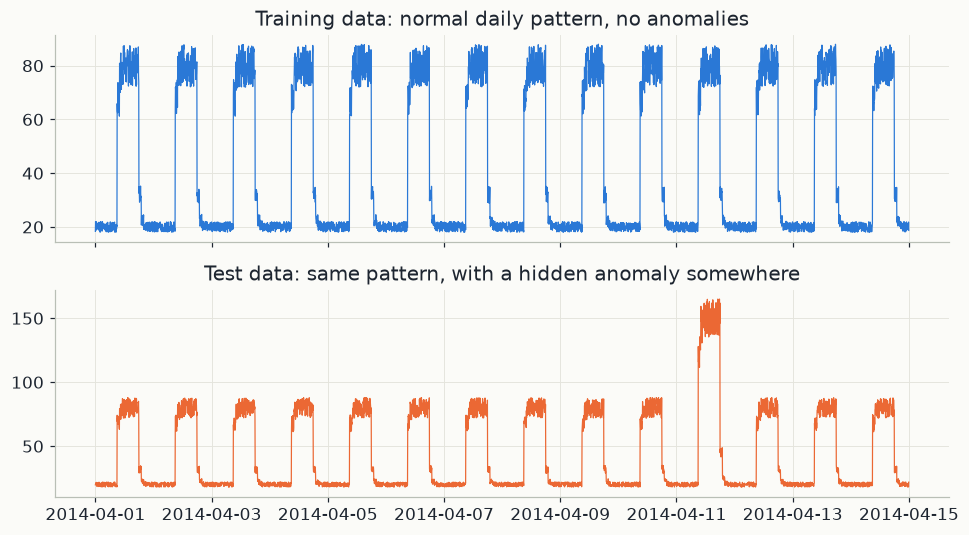

In [2]:
train_df = pd.read_csv("data/art_daily_small_noise.csv", parse_dates=["timestamp"])
test_df = pd.read_csv("data/art_daily_jumpsup.csv", parse_dates=["timestamp"])
print(f"train: {len(train_df)} points, test: {len(test_df)} points, "
      f"both at {train_df['timestamp'].diff().mode()[0]} resolution")

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axes[0].plot(train_df["timestamp"], train_df["value"], color=mlutils.BLUE, lw=0.8)
axes[0].set_title("Training data: normal daily pattern, no anomalies")
axes[1].plot(test_df["timestamp"], test_df["value"], color=mlutils.ORANGE, lw=0.8)
axes[1].set_title("Test data: same pattern, with a hidden anomaly somewhere")
fig.tight_layout()

## 6. Windows, and a convolutional autoencoder

As set out in section 2, we slice both series into overlapping 2-hour windows (24 points at 5-minute
resolution) and normalise using the **training** mean and standard deviation only —
the test set's own statistics must never leak into preprocessing, exactly as in
chapter 08.

In [3]:
mu, sigma = train_df["value"].mean(), train_df["value"].std()
train_v = (train_df["value"].values - mu) / sigma
test_v = (test_df["value"].values - mu) / sigma

window = 24
def make_windows(values, w):
    return np.stack([values[i:i + w] for i in range(len(values) - w + 1)])

X_train = make_windows(train_v, window)[..., np.newaxis].astype("float32")
X_test = make_windows(test_v, window)[..., np.newaxis].astype("float32")
print(f"train windows: {X_train.shape}, test windows: {X_test.shape}")

train windows: (4009, 24, 1), test windows: (4009, 24, 1)


In [4]:
inp = tf.keras.Input(shape=(window, 1))
z = tf.keras.layers.Conv1D(16, 5, activation="relu", padding="same", strides=2)(inp)
z = tf.keras.layers.Conv1D(8, 5, activation="relu", padding="same", strides=2)(z)      # bottleneck: 6x8
z = tf.keras.layers.Conv1DTranspose(8, 5, activation="relu", padding="same", strides=2)(z)
z = tf.keras.layers.Conv1DTranspose(16, 5, activation="relu", padding="same", strides=2)(z)
out = tf.keras.layers.Conv1DTranspose(1, 5, padding="same")(z)

autoencoder = tf.keras.Model(inp, out)
autoencoder.compile(optimizer="adam", loss="mae")
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 12, 16)         │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 6, 8)           │           648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose                │ (None, 12, 8)          │           328 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_1              │ (None, 24, 16)         │           656 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_2              │ (None, 24, 1)          │            81 │
│ (Conv1DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,809 (7.07 KB)

 Trainable params: 1,809 (7.07 KB)

 Non-trainable params: 0 (0.00 B)

final train MAE: 0.0524, val MAE: 0.0545


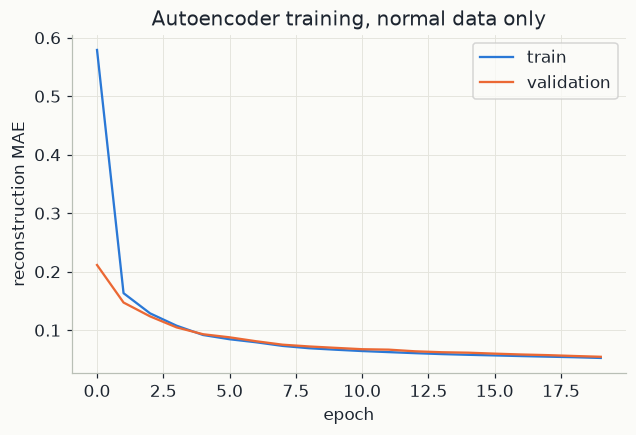

In [5]:
history = autoencoder.fit(X_train, X_train, epochs=20, batch_size=64,
                           validation_split=0.1, verbose=0)
print(f"final train MAE: {history.history['loss'][-1]:.4f}, "
      f"val MAE: {history.history['val_loss'][-1]:.4f}")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(history.history["loss"], color=mlutils.BLUE, label="train")
ax.plot(history.history["val_loss"], color=mlutils.ORANGE, label="validation")
ax.set(xlabel="epoch", ylabel="reconstruction MAE", title="Autoencoder training, normal data only")
ax.legend()

## 7. Setting a threshold from normal data alone

The threshold comes entirely from the *training* set's own reconstruction error — we
still haven't looked at the test set's anomaly at all. The simplest reasonable choice:
the worst reconstruction error the model ever produced on data it knows is normal.
Anything worse than that, on new data, is suspicious.

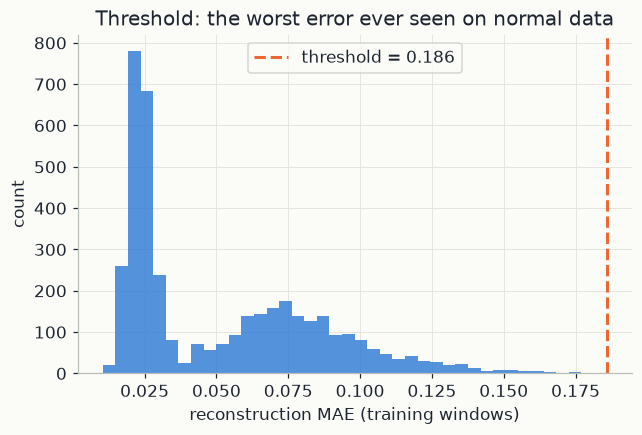

In [6]:
train_recon = autoencoder.predict(X_train, verbose=0)
train_mae = np.mean(np.abs(train_recon - X_train), axis=(1, 2))
threshold = train_mae.max()

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hist(train_mae, bins=40, color=mlutils.BLUE, alpha=0.8)
ax.axvline(threshold, color=mlutils.ORANGE, lw=2, ls="--", label=f"threshold = {threshold:.3f}")
ax.set(xlabel="reconstruction MAE (training windows)", ylabel="count",
       title="Threshold: the worst error ever seen on normal data")
ax.legend()

## 8. Flagging anomalies in unseen data

In [7]:
test_recon = autoencoder.predict(X_test, verbose=0)
test_mae = np.mean(np.abs(test_recon - X_test), axis=(1, 2))
anomalous = np.where(test_mae > threshold)[0]
print(f"flagged {len(anomalous)} of {len(test_mae)} windows as anomalous")
if len(anomalous):
    start = test_df["timestamp"].iloc[anomalous.min()]
    end = test_df["timestamp"].iloc[anomalous.max() + window - 1]
    print(f"flagged windows span {start} to {end}")

flagged 69 of 4009 windows as anomalous
flagged windows span 2014-04-11 07:05:00 to 2014-04-12 10:45:00


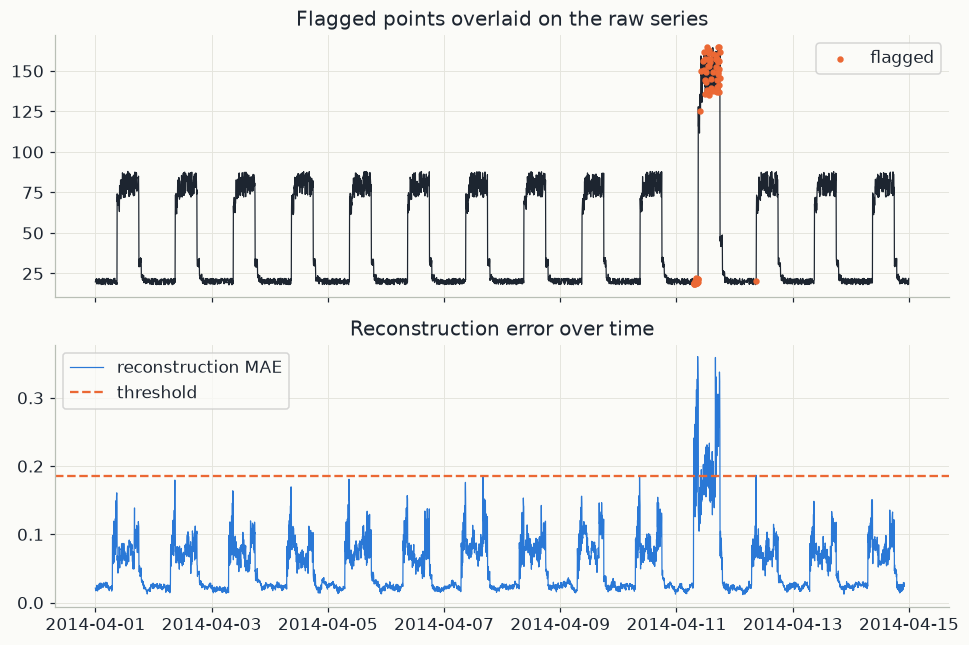

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(test_df["timestamp"], test_df["value"], color=mlutils.INK, lw=0.8)
flag_times = test_df["timestamp"].iloc[anomalous]
flag_values = test_df["value"].iloc[anomalous]
axes[0].scatter(flag_times, flag_values, color=mlutils.ORANGE, s=10, zorder=5, label="flagged")
axes[0].set_title("Flagged points overlaid on the raw series")
axes[0].legend()

mae_times = test_df["timestamp"].iloc[:len(test_mae)]    # one MAE value per window start
axes[1].plot(mae_times, test_mae, color=mlutils.BLUE, lw=0.8, label="reconstruction MAE")
axes[1].axhline(threshold, color=mlutils.ORANGE, ls="--", label="threshold")
axes[1].set_title("Reconstruction error over time")
axes[1].legend()
fig.tight_layout()

The flagged windows form one contiguous block, right where the injected level-jump
sits — exactly what an unsupervised detector trained on nothing but "normal" data
should produce: no labelled anomalies were used anywhere in training or in setting
the threshold, yet it isolates the anomalous stretch cleanly.

## Exercises

### Exercise 1: A stricter threshold
Try `threshold = train_mae.mean() + 3 * train_mae.std()` instead of the max. Does it
flag more or fewer windows? Look at whether any of the newly-flagged windows fall
outside the true anomaly period (false positives).

<details><summary>Solution</summary>

```python
threshold2 = train_mae.mean() + 3 * train_mae.std()
anomalous2 = np.where(test_mae > threshold2)[0]
print(len(anomalous2))
```
A mean-plus-k-sigma threshold is usually a bit stricter (lower) than the training
max, so it flags a similar or slightly larger contiguous block; whether it introduces
false positives depends on how heavy-tailed the *normal* reconstruction errors are.
</details>

### Exercise 2: A different anomaly type
Rerun section 8 using `art_flatline.csv` or `art_daily_jumpsdown.csv` as the test set
instead (same folder). Does the same autoencoder, trained only once on
`art_daily_small_noise.csv`, still flag the new anomaly correctly?

<details><summary>Solution</summary>

The trained autoencoder generalises to other anomaly *shapes* it never saw, because it
was never trained to recognise any specific anomaly — only to reconstruct normal
patterns well. A flatline or a downward jump both reconstruct badly for the same
reason a jump-up does: the model never learned to compress that shape.
</details>

## Key takeaways

- An autoencoder trained only on normal data learns to compress and reconstruct
  *that* pattern well; reconstruction error becomes an anomaly score with no labelled
  anomalies required anywhere in training.
- The detection threshold should come from the training data's own error
  distribution, never by peeking at the test set.
- This approach transfers to any anomaly *shape* the training data didn't contain —
  it doesn't need to know what an anomaly looks like in advance, only what normal
  looks like.